# Naive Bayes Classification to Predict Titanic Survival

**Deep Dive Coding Data Science Bootcamp Sample Project**

---
Robert Citek - October 5th, 2026


## Problem Definition

State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.  Mention which model will be used, if known.

We want to predict whether a given person will survive or perish in the Titanic disaster. This is a supervised, binary classification problem, where the target is a given person's survival status. To do this, we use a Gaussian Naive Bayes model to make our predictions.

## Data Collection/Sources

### Data Overview

This data comes from [Kaggle](https://www.kaggle.com/c/titanic/data), which was then copied to AWS for easy access.

https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv


### Imports

In [1]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File Paths

Create a variable `url` that contains the web link to the CSV data

In [2]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'    # insert url here
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'

### Load data

Load the data into a data frame named `titanic_df`.

In [4]:
# load data
titanic_df = pd.read_csv( url )
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### head

Look at the first few rows

In [5]:
# first few rows
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### tail

Look at the last few rows


In [6]:
# last few rows
titanic_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### shape


In [7]:
# shape of data frame
titanic_df.shape

(891, 12)

### size


In [8]:
# size of data frame
titanic_df.size

10692

### Summary meta-data

Run the `info()` method on the data frame.


In [9]:
# display meta-data
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary statistics

Summary statistics give you a quick overview of the data.  Some items to spot check:
- the Target:
  - look for nulls
    - null will be culled
  - look at min, max, median, and mean
    - is it a categorical field masquerading as a number?
- the Features:
  - numerical
    - look at min, max, median, and mean
      - a min=1 and max=count suggests an ID
  - categorical
    - look at unique and freq
      - freq=1, unique=count suggests an ID
      - freq=count suggests a meaningless feature

Run the `describe()` method on the data frame.

In [10]:
# display summary statistics
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### target value_counts()


The target should be the first field that you look at.  Its data type will tell you what kind of machine learning problem this is ( classification or regression. ) Any nulls should be culled.  You can check for any skew in the data set.

In [16]:
# Define target
target_col = 'Survived'
target_col

'Survived'

In [14]:
# value_counts on target ; include nulls
titanic_df[target_col].value_counts( dropna = False )

,count
Survived,
0,549
1,342


In [17]:
# normalized value_counts on target ; include nulls
titanic_df[target_col].value_counts( dropna = False, normalize = True ) * 100

,proportion
Survived,
0,61.616162
1,38.383838


### Nulls



In [18]:
# look for nulls
titanic_df.isnull().sum().sort_values( ascending = False )

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [20]:
# look for nulls, displaying relative frequency
(titanic_df.isnull().sum() / titanic_df.shape[0]).sort_values( ascending = False ) * 100

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


### dtypes - column data types

Which data types would be appropriate for Gaussian Naive Bayes?


In [21]:
# display data types
titanic_df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


### Unique elements


If the total number of unique items in a field equals the number of rows, that suggests those fields are unique IDs ( e.g. names, IDs ) and should be dropped.


In [22]:
# number of unique elements in a column
titanic_df.nunique().sort_values( ascending = False )

,0
PassengerId,891
Name,891
Ticket,681
Fare,248
Cabin,147
Age,88
SibSp,7
Parch,7
Embarked,3
Pclass,3


## Data Cleaning


### Backup #1


In [23]:
# make backup
titanic_df_bak = titanic_df.copy()
titanic_df_bak

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [24]:
# restore from backup
titanic_df = titanic_df_bak.copy()
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Keep only the target and two features

Select `Survived` for the target and `Age` and `Fare` for the features

In [27]:
# select the target and one feature
target_cols  = [target_col] # 'Survived'
feature_cols = ['Age', 'Fare']
titanic_df = titanic_df[target_cols + feature_cols]
titanic_df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


### Backup #2


In [28]:
# make backup
titanic_df_bak2 = titanic_df.copy()
titanic_df_bak2

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [29]:
# restore from backup
titanic_df = titanic_df_bak2.copy()
titanic_df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


### Address any rows with nulls

- If the number of nulls in a column is low, it would be easiest to drop the row.
- If the number of nulls in a column is high, it would be easiest to drop the column.
- If the number of nulls in a column is between the low and high, one should impute values for the nulls.


In [30]:
titanic_df.isnull().sum().sort_values( ascending = False )

,0
Age,177
Survived,0
Fare,0


#### Impute

Impute with the median.


In [32]:
# Calculate the median
median_age = titanic_df['Age'].median()
median_age

28.0

In [33]:
# Assign median to nulls
titanic_df.fillna( {'Age': median_age}, inplace = True )
titanic_df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,28.0,23.4500
889,1,26.0,30.0000


In [34]:
# Verify there are no nulls
titanic_df.isnull().sum().sort_values( ascending = False )

,0
Survived,0
Age,0
Fare,0


In [35]:
# Verify median is about the same as before
titanic_df['Age'].median()

28.0

## Exploratory Data Analysis


GNB has two requirements:
1. the features are normally distributed
1. the features are not correlated with each other

### normal distribution of features: histogram


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >]], dtype=object)

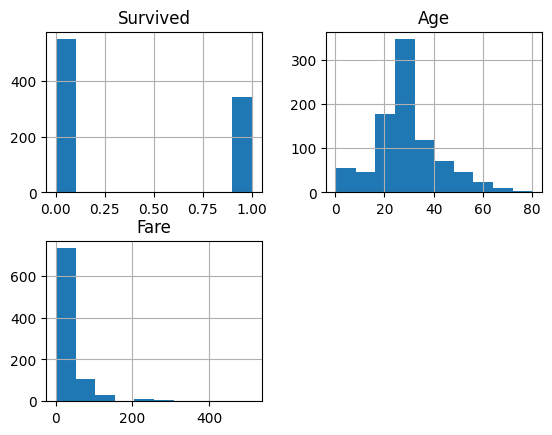

In [36]:
# Display a histogram
titanic_df.hist()

### independence of features: correlation

In [37]:
# Calculate a correlation matrix
column_correlations = titanic_df.corr()
column_correlations

,Survived,Age,Fare
Survived,1.000000,-0.064910,0.257307
Age,-0.064910,1.000000,0.096688
Fare,0.257307,0.096688,1.000000


<Axes: >

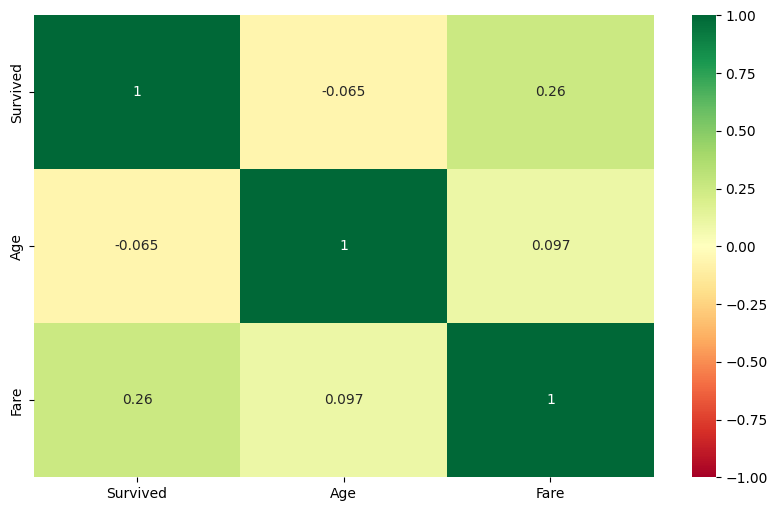

In [38]:
# Display the correlation matrix
plt.figure(figsize = (10, 6))
sns.heatmap(
    column_correlations,
    annot = True,
    vmin = -1,
    vmax = 1,
    cmap = 'RdYlGn'
)

## Processing

In [57]:
titanic_df_bak3 = titanic_df.copy()
titanic_df_bak3

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,28.0,23.4500
889,1,26.0,30.0000


In [58]:
titanic_df = titanic_df_bak3.copy()
titanic_df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,28.0,23.4500
889,1,26.0,30.0000


### Balance the data set


In [41]:
# Display value counts of target
titanic_df[target_col].value_counts()

,count
Survived,
0,549
1,342


In [43]:
# Alternative view of data:
titanic_df[target_col].value_counts( normalize = True ) * 100

,proportion
Survived,
0,61.616162
1,38.383838


In [50]:
# Place minority class in one data frame
filter_minority = (titanic_df['Survived'] == 1)
titanic_df_minority = titanic_df[ filter_minority ]
titanic_df_minority

,Survived,Age,Fare
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
8,1,27.0,11.1333
9,1,14.0,30.0708
...,...,...,...
875,1,15.0,7.2250
879,1,56.0,83.1583
880,1,25.0,26.0000
887,1,19.0,30.0000


In [56]:
# Create downsample of majority class in another data frame
filter_majority = (titanic_df['Survived'] == 0)
titanic_df_majority = titanic_df[ filter_majority ]
titanic_df_majority.sample(titanic_df_minority.shape[0])

,Survived,Age,Fare
488,0,30.0,8.0500
332,0,38.0,153.4625
613,0,28.0,7.7500
532,0,17.0,7.2292
87,0,28.0,8.0500
...,...,...,...
805,0,31.0,7.7750
522,0,28.0,7.2250
111,0,14.5,14.4542
137,0,37.0,53.1000


In [60]:
titanic_df_majority = titanic_df_majority.sample(titanic_df_minority.shape[0])
titanic_df_majority

,Survived,Age,Fare
428,0,28.0,7.7500
588,0,22.0,8.0500
739,0,28.0,7.8958
805,0,31.0,7.7750
836,0,21.0,8.6625
...,...,...,...
83,0,28.0,47.1000
452,0,30.0,27.7500
203,0,45.5,7.2250
418,0,30.0,13.0000


In [66]:
# Combine data frames
titanic_df = pd.concat([titanic_df_majority, titanic_df_minority], ignore_index = True)
titanic_df

,Survived,Age,Fare
0,0,28.0,7.7500
1,0,22.0,8.0500
2,0,28.0,7.8958
3,0,31.0,7.7750
4,0,21.0,8.6625
...,...,...,...
679,1,15.0,7.2250
680,1,56.0,83.1583
681,1,25.0,26.0000
682,1,19.0,30.0000


In [67]:
# Verify target counts
titanic_df[target_col].value_counts()

,count
Survived,
0,342
1,342


In [68]:
# Split data frame into target and features
target = titanic_df[ target_col ]
features = titanic_df.drop( columns = [target_col] )

In [69]:
# Verify features
features

,Age,Fare
0,28.0,7.7500
1,22.0,8.0500
2,28.0,7.8958
3,31.0,7.7750
4,21.0,8.6625
...,...,...
679,15.0,7.2250
680,56.0,83.1583
681,25.0,26.0000
682,19.0,30.0000


In [70]:
type(features), features.ndim

(pandas.core.frame.DataFrame, 2)

In [71]:
# Verify target
target

,Survived
0,0
1,0
2,0
3,0
4,0
...,...
679,1
680,1
681,1
682,1


In [72]:
type(target), target.ndim

(pandas.core.series.Series, 1)

### Multiple Cross Validation ( CV )

Create a CV loop with 100 iterations.  Capture performance metric in an array names `results`.
Use accuracy for the performance metric.


In [88]:
# Multiple CV loop

# Create array to hold results (accuracies)
n = 1000
accuracies = np.zeros(n)

# Multiple CV loop
for i in range(n):

  # Train Test Split
  X_train, X_test, y_train, y_test = train_test_split( features, target, test_size = 0.25 )

  # Create an empty GNB model
  modelGNB = GaussianNB()

  # Train ( fit ) the model
  modelGNB.fit(X_train, y_train)

  # Make predictions using the model
  y_pred = modelGNB.predict(X_test)

  # Calculate the accuracy and save to array
  accuracies[i] = metrics.accuracy_score(y_test, y_pred)

In [89]:
accuracies

array([0.64327485, 0.60818713, 0.59649123, 0.61403509, 0.60233918,
       0.60818713, 0.64912281, 0.60818713, 0.64327485, 0.55555556,
       0.53216374, 0.60233918, 0.51461988, 0.61403509, 0.60818713,
       0.60233918, 0.58479532, 0.59064327, 0.55555556, 0.64912281,
       0.59649123, 0.58479532, 0.57894737, 0.5380117 , 0.60233918,
       0.61988304, 0.55555556, 0.64327485, 0.62573099, 0.59064327,
       0.54385965, 0.61403509, 0.59064327, 0.59649123, 0.57309942,
       0.5380117 , 0.67251462, 0.59064327, 0.57309942, 0.61403509,
       0.57894737, 0.59649123, 0.61403509, 0.60818713, 0.65497076,
       0.61988304, 0.56140351, 0.58479532, 0.61403509, 0.63157895,
       0.63157895, 0.60818713, 0.51461988, 0.61988304, 0.56140351,
       0.56725146, 0.60818713, 0.5497076 , 0.57894737, 0.61403509,
       0.63157895, 0.58479532, 0.6374269 , 0.60818713, 0.57309942,
       0.56725146, 0.61988304, 0.60233918, 0.56725146, 0.59649123,
       0.61988304, 0.56725146, 0.63157895, 0.60233918, 0.60818

#### Performance

We'll meassure accuracy, which is the proportions of the number correctly predicted, which is mathematically the same as one minus the proportion incorrectly predicted.

In [90]:
# Calculate mean of results
accuracies.mean()

np.float64(0.5938245614035088)

Text(113.9222222222222, 0.5, 'Predicted')

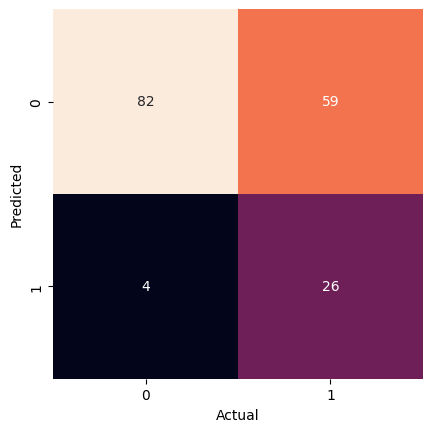

In [91]:
# Display a confusion matrix
matrix = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    matrix.T,
    square = True,
    annot = True,
    fmt = 'd',
    cbar = False
)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: >

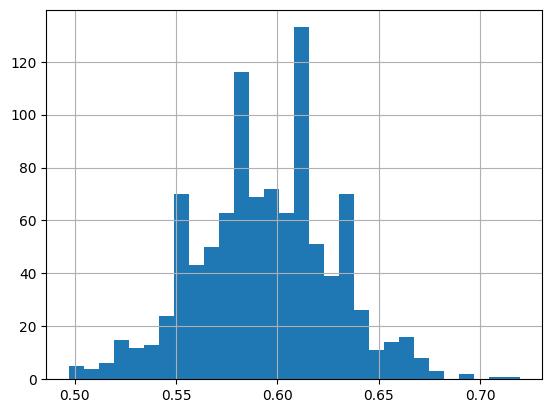

In [92]:
# Display a histogram of the results
pd.Series(accuracies).hist(bins = 30)

## Communication of Results

Conclusion:

- Balancing the data set by undersampling (downsampling) has lowered the accuracy of the model: true negatives (82 / 171) and true positives (26 / 171) make up a lower percentage of the total test data (~62%) than when using an unblanced data set (around 67%).
- This could be due to using a smaller training data set, and having a smaller testing data set.
- The proportion of correct true positives, however, is higher than before.
- The proportion of false negatives is higher than before as well.

Future work:

- Testing with more features and/or different combinations of features, with and without using a balanced data set.
- Trying out different models.
- Trying out oversampling (or upsampling) rather than truncating the data set.
